In [9]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Hp\Desktop\india_cancer_patients_2022_2025.csv")
print(df)





           Patient_ID  Age  Gender        State        City  \
0      IND-CAN-100000   82  Female        Delhi   New Delhi   
1      IND-CAN-100001   45  Female  West Bengal     Kolkata   
2      IND-CAN-100002   47    Male   Chandigarh  Chandigarh   
3      IND-CAN-100003    1  Female        Delhi   New Delhi   
4      IND-CAN-100004   52  Female  Maharashtra      Mumbai   
...               ...  ...     ...          ...         ...   
99995  IND-CAN-199995   50  Female        Delhi   New Delhi   
99996  IND-CAN-199996   32  Female    Karnataka   Bengaluru   
99997  IND-CAN-199997   92  Female  West Bengal     Kolkata   
99998  IND-CAN-199998   60  Female   Tamil Nadu     Chennai   
99999  IND-CAN-199999   69  Female   Chandigarh  Chandigarh   

                               Hospital_Name      Cancer_Type      Stage  \
0              Rajiv Gandhi Cancer Institute   Stomach Cancer  Stage III   
1                        Tata Medical Center  Cervical Cancer   Stage IV   
2              

In [10]:
df.info()
df.head()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Patient_ID       100000 non-null  object 
 1   Age              100000 non-null  int64  
 2   Gender           100000 non-null  object 
 3   State            100000 non-null  object 
 4   City             100000 non-null  object 
 5   Hospital_Name    100000 non-null  object 
 6   Cancer_Type      100000 non-null  object 
 7   Stage            100000 non-null  object 
 8   Treatment_Type   100000 non-null  object 
 9   Diagnosis_Date   100000 non-null  object 
 10  Survival_Months  100000 non-null  float64
 11  Status           100000 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 9.2+ MB


,Age,Survival_Months
count,100000.000000,100000.000000
mean,53.899460,20.333353
std,13.653781,14.156450
min,1.000000,1.000000
25%,45.000000,8.200000
50%,54.000000,17.200000
75%,63.000000,30.600000
max,95.000000,53.300000


In [11]:
df.isnull().sum()

Patient_ID         0
Age                0
Gender             0
State              0
City               0
Hospital_Name      0
Cancer_Type        0
Stage              0
Treatment_Type     0
Diagnosis_Date     0
Survival_Months    0
Status             0
dtype: int64

In [12]:
df.duplicated().sum()
df=df.drop_duplicates()



In [13]:
df['Gender'].value_counts()
df['Stage'].value_counts()
df['State'].value_counts()
df['Age'].describe()




count    100000.000000
mean         53.899460
std          13.653781
min           1.000000
25%          45.000000
50%          54.000000
75%          63.000000
max          95.000000
Name: Age, dtype: float64

In [14]:
df['Cancer_Type'].value_counts()

Cancer_Type
Breast Cancer        28169
Oral Cancer          16259
Cervical Cancer      13881
Lung Cancer          12046
Colorectal Cancer     7935
Stomach Cancer        7923
Prostate Cancer       5809
Leukemia              4070
Ovarian Cancer        3908
Name: count, dtype: int64

In [15]:
df['Gender'].value_counts()

Gender
Female    67151
Male      32849
Name: count, dtype: int64

In [16]:
df['State'].value_counts()

State
Delhi          19938
Karnataka      10163
Chandigarh     10108
Gujarat        10105
Kerala         10030
Tamil Nadu      9997
Maharashtra     9954
Telangana       9885
West Bengal     9820
Name: count, dtype: int64

In [17]:
df['Gender']=df['Gender'].str.title()

In [18]:
df['Gender'].unique()
df['Cancer_Type'].unique()


array(['Stomach Cancer', 'Cervical Cancer', 'Oral Cancer', 'Leukemia',
       'Lung Cancer', 'Colorectal Cancer', 'Prostate Cancer',
       'Breast Cancer', 'Ovarian Cancer'], dtype=object)

In [19]:
df=df.apply(lambda x:x.str.strip() if 
x.dtype == "object" else x)


In [20]:
df['Survival_Months'].describe()

count    100000.000000
mean         20.333353
std          14.156450
min           1.000000
25%           8.200000
50%          17.200000
75%          30.600000
max          53.300000
Name: Survival_Months, dtype: float64

In [21]:
print(df['Gender'].unique())
print(df['Stage'].unique())
print(df['Status'].unique())

['Female' 'Male']
['Stage III' 'Stage IV' 'Stage II' 'Stage I']
['Deceased' 'Alive']


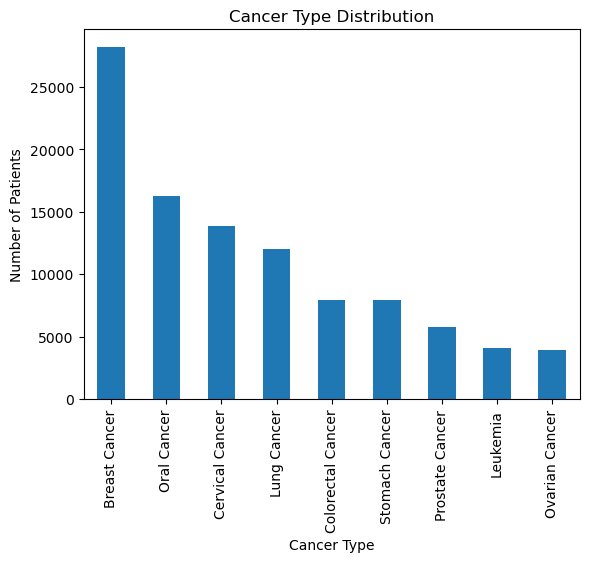

In [22]:
import matplotlib.pyplot as plt
df['Cancer_Type'].value_counts().plot(kind='bar')
plt.title('Cancer Type Distribution')
plt.xlabel('Cancer Type')
plt.ylabel('Number of Patients')
plt.show()






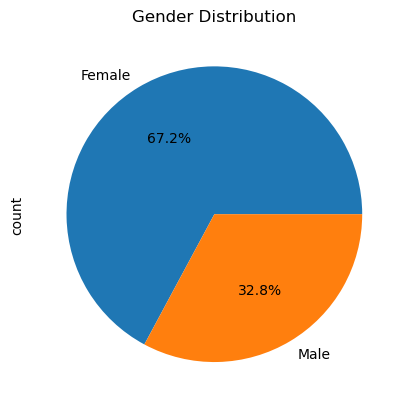

In [23]:
df['Gender'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()



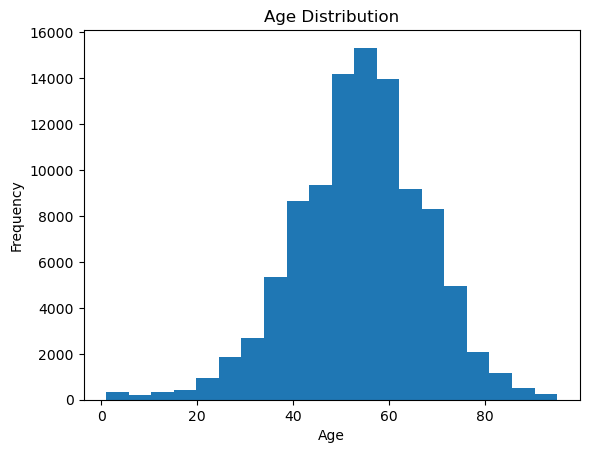

In [24]:
df['Age'].plot(kind='hist', bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()




In [25]:
print(df.columns)

Index(['Patient_ID', 'Age', 'Gender', 'State', 'City', 'Hospital_Name',
       'Cancer_Type', 'Stage', 'Treatment_Type', 'Diagnosis_Date',
       'Survival_Months', 'Status'],
      dtype='object')


In [26]:
y=df['Status']
X=df.drop(columns=['Patient_ID','Hospital_Name','Diagnosis_Date','City','State','Status'],axis=1)



In [27]:
X_encoded=pd.get_dummies(X,drop_first=True)

In [28]:
from sklearn.model_selection import train_test_split
y = df['Status']
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
model = DecisionTreeClassifier(max_depth=8,min_samples_split=10,random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Decision Tree Accuracy:",accuracy_score(y_test,y_pred))

Decision Tree Accuracy: 0.7873


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf_model=RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)
print("Random Forest Accuracy:",accuracy_score(y_test,y_pred_rf))






Random Forest Accuracy: 0.7917


In [39]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_tuned))


              precision    recall  f1-score   support

       Alive       0.74      0.67      0.70      7341
    Deceased       0.82      0.86      0.84     12659

    accuracy                           0.79     20000
   macro avg       0.78      0.76      0.77     20000
weighted avg       0.79      0.79      0.79     20000



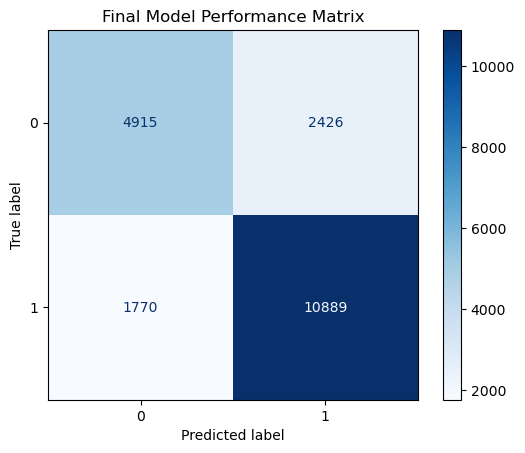

In [40]:
import matplotlib.pyplot as plt 
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(y_test,y_pred_tuned)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Final Model Performance Matrix")
plt.show()





